# Lecture 20: False Discovery Rate and Benjamini-Hochberg

**Data 145, Spring 2026: Evidence and Uncertainty**
**Instructors:** Ani Adhikari, William Fithian

---

**Please run the setup cell below before reading.**

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

COLOR_DATA = 'steelblue'
COLOR_APPROX = 'firebrick'

plt.rcParams.update({
    'figure.figsize': (10, 4),
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Load the prostate z-scores from Lecture 19
z_scores = pd.read_csv('../lec19/prostate_zscores.csv')['zscore'].values
m = len(z_scores)
p_vals = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))
print('Setup complete.')

Setup complete.


## Introduction

In Lecture 19, we saw that testing 6,033 genes for association with prostate cancer produced 478 significant results at $\alpha = 0.05$ --- but Bonferroni, which controls the familywise error rate (FWER), reduced this to just 3. We lost almost everything.

FWER treats even a single false rejection as catastrophic. But in a screening context --- where we're generating candidates for follow-up --- a few false leads among many real ones may be perfectly tolerable. Today we introduce the **false discovery rate (FDR)**, a more permissive error criterion, and the **Benjamini-Hochberg (BH) procedure** for controlling it.

---

## 1. Motivation: Controlling the Fraction of False Discoveries

Recall from Lecture 19: we test $m = 6{,}033$ genes at level $\alpha$, rejecting $H_{0i}$ whenever $p_i \leq \alpha$. If the null $p$-values are uniform, we expect roughly $\alpha m$ false rejections. The **false discovery proportion** is roughly $\alpha m / R$ where $R$ is the total number of rejections.

What happens as we lower $\alpha$?

In [2]:
# Motivation: lowering the threshold
print(f'{"Threshold":>12s}  {"Rejections":>10s}  {"Expected false":>14s}  {"Est. FDP":>10s}')
print('-' * 52)
for alpha in [0.05, 0.01, 0.001]:
    R = (p_vals < alpha).sum()
    exp_false = m * alpha
    fdp = exp_false / R if R > 0 else 0
    print(f'{alpha:12.3f}  {R:10d}  {exp_false:14.0f}  {fdp:10.0%}')

   Threshold  Rejections  Expected false    Est. FDP
----------------------------------------------------
       0.050         478             302         63%
       0.010         172              60         35%
       0.001          60               6         10%


At $\alpha = 0.05$, about 63% of our discoveries may be false --- most of what we found could be noise. At $\alpha = 0.01$, the false discovery proportion drops to about 35%, but we still have 172 discoveries. At $\alpha = 0.001$, we're down to 60 discoveries with only $\sim 6$ expected to be false --- about 10%.

So by lowering the threshold we can control the *fraction* of discoveries that are false. But we chose $\alpha = 0.001$ by trial and error. Can we formalize this?

The **Benjamini-Hochberg procedure** does exactly this: it finds the most liberal threshold $t$ such that the estimated false discovery proportion $\alpha m/R_t$ is at most $\alpha$. Before describing it, let us define the error criterion it controls.

---

## 2. The False Discovery Rate

### Notation

As in Lecture 19, let $\mathcal{R}$ be the set of rejected hypotheses and $\mathcal{H}_0$ the set of true nulls.

- $R = |\mathcal{R}|$: total number of rejections ("discoveries")
- $V = |\mathcal{R} \cap \mathcal{H}_0|$: number of **false** discoveries (unobservable)

### FDP and FDR

The **false discovery proportion** is:
$$\text{FDP} = \frac{V}{R \vee 1}$$
where $R \vee 1 = \max(R, 1)$ (convention: $\text{FDP} = 0$ when $R = 0$).

The **false discovery rate** is its expectation:
$$\text{FDR} = E\!\left[\frac{V}{R \vee 1}\right].$$

FDR controls the expected *proportion* of false discoveries, not the probability of *any* false discovery. When we say a procedure has FDR $\leq \alpha$, we mean: on average, at most a fraction $\alpha$ of the discoveries are false.

Note: if all nulls are true ($m_0 = m$), then every rejection is false and $\text{FDP} = 1$ whenever $R > 0$. So FDR $\leq \alpha$ still provides meaningful protection in the worst case.

### Comparison with FWER

When we are making a lot of discoveries, FDR and FWER can be very different. FWER penalizes even one false positive among thousands of true positives. FDR says: as long as the *fraction* of false discoveries is small, we're fine.

---

## 3. The Benjamini-Hochberg Procedure

### The Procedure

Given $p$-values $p_1, \ldots, p_m$ and a target FDR level $\alpha$:

1. Sort the $p$-values: $p_{(1)} \leq p_{(2)} \leq \cdots \leq p_{(m)}$.
2. Find the largest $k$ such that $p_{(k)} \leq \alpha k / m$.
3. Reject $H_{0(1)}, \ldots, H_{0(k)}$ (the $k$ smallest $p$-values).

This is called a **step-up** procedure: we search from $k = m$ down to $k = 1$ and stop at the first $k$ where $p_{(k)} \leq \alpha k/m$.

### The Ordered $p$-Value Plot

The BH procedure has a beautiful graphical interpretation. Plot the sorted $p$-values $p_{(k)}$ against their rank $k$. The BH threshold is the line $y = (\alpha/m) \cdot k$ through the origin. We reject all $p$-values that fall below this line.

Compare this to Bonferroni, which uses the *horizontal* line $y = \alpha/m$. The BH line rises with $k$, giving more room for discoveries when many $p$-values are small.

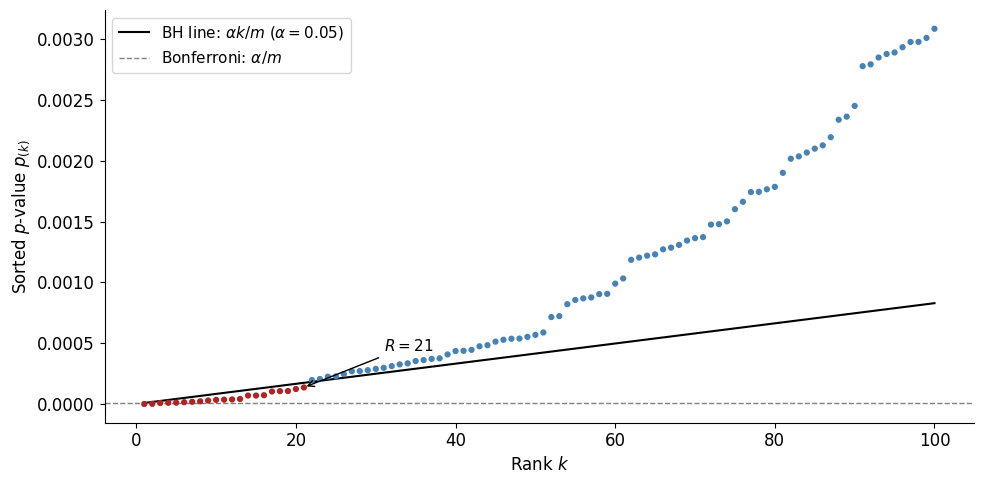

BH at FDR = 0.05: 21 rejections
Bonferroni: 3 rejections


In [3]:
# Figure 1: Ordered p-value plot with BH line (FDR = 0.05)
alpha_bh = 0.05
sorted_p = np.sort(p_vals)
ranks = np.arange(1, m + 1)
bh_line = alpha_bh * ranks / m

# Find BH rejections
bh_mask = sorted_p <= bh_line
R_bh = np.max(np.where(bh_mask)[0]) + 1 if bh_mask.any() else 0

# Zoom in on the interesting region (first 100 p-values)
n_show = 100
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(ranks[:n_show], sorted_p[:n_show], s=12, zorder=3,
           color=[COLOR_APPROX if k < R_bh else COLOR_DATA for k in range(n_show)])
ax.plot(ranks[:n_show], bh_line[:n_show], color='black', linewidth=1.5,
        label=f'BH line: $\\alpha k/m$ ($\\alpha = {alpha_bh}$)')
ax.axhline(alpha_bh / m, color='gray', linestyle='--', linewidth=1,
           label=f'Bonferroni: $\\alpha/m$')
ax.set_xlabel('Rank $k$')
ax.set_ylabel('Sorted $p$-value $p_{(k)}$')
ax.legend(fontsize=11)

# Mark the BH cutoff
ax.annotate(f'$R = {R_bh}$', xy=(R_bh, sorted_p[R_bh-1]),
            xytext=(R_bh + 10, sorted_p[R_bh-1] + 0.0003),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.show()

print(f'BH at FDR = {alpha_bh}: {R_bh} rejections')
print(f'Bonferroni: {(p_vals < alpha_bh/m).sum()} rejections')

*__Figure 1.__ Ordered $p$-value plot for the prostate cancer data (first 100 of 6,033). Red points fall below the BH line (solid black) and are rejected; blue points are retained. The horizontal dashed line is the Bonferroni threshold $\alpha/m$. BH rejects 21 genes at FDR $= 0.05$, compared to Bonferroni's 3.*

### Intuition: BH as Estimated FDP Control

Why does the BH procedure control the false discovery rate? The key insight connects back to our motivation.

For any rejection threshold $t$, the number of rejections is $R_t = \#\{i : p_i \leq t\}$ and the number of false rejections is $V_t = \#\{i \in \mathcal{H}_0 : p_i \leq t\}$. If null $p$-values are $\text{Unif}(0,1)$, then $E[V_t] = m_0 t \leq mt$. So:
$$\widehat{\text{FDP}}_t = \frac{mt}{R_t \vee 1}$$
is a conservative estimate of $\text{FDP}_t = V_t / (R_t \vee 1)$ (it overestimates because it uses $m$ instead of $m_0$).

The BH procedure simply chooses the largest threshold $t$ for which $\widehat{\text{FDP}}_t \leq \alpha$. This is equivalent to the step-up rule: at $t = p_{(k)}$, we have $R_t = k$, so
$$\widehat{\text{FDP}}_t = \frac{m p_{(k)}}{k} \leq \alpha \quad \Longleftrightarrow \quad p_{(k)} \leq \frac{\alpha k}{m}.$$

So, when the BH procedure makes $R$ rejections, we can think of the BH procedure as finding the threshold $\hat{t} = \alpha R/m$ and rejecting all of the $p$-values below $\hat{t}$.

This is exactly the logic we used in Section 1: keep lowering the threshold until the estimated fraction of false discoveries is acceptable. BH automates this. (Why don't we need to worry about values of $t$ that are in between $p$-values?)

---

## 4. Proof of FDR Control

We now prove that BH controls FDR at level $\alpha m_0/m \leq \alpha$ when $p$-values are independent and null $p$-values are $\text{Unif}(0,1)$.

### Step 1: Decompose FDR as a Sum

Write $V = \sum_{i \in \mathcal{H}_0} V_i$ where $V_i = 1\{H_{0i} \text{ rejected}\} = 1\{p_i \leq \alpha R / m\}$. Then:
$$\text{FDR} = E\!\left[\frac{V}{R \vee 1}\right] = \sum_{i \in \mathcal{H}_0} E\!\left[\frac{V_i}{R \vee 1}\right].$$

It suffices to show that each term is at most $\alpha/m$, because then:
$$\text{FDR} \leq m_0 \cdot \frac{\alpha}{m} \leq \alpha.$$

### Step 2: The Key Observation

Fix $i \in \mathcal{H}_0$. Define $p^{(i \leftarrow 0)}$ to be the vector of $p$-values with $p_i$ replaced by $0$. For example, if $m = 5$ and $i = 3$, then $p^{(3 \leftarrow 0)} = (p_1, p_2, 0, p_4, p_5)$.

Let $R^0 = R(p^{(i \leftarrow 0)})$ be the number of BH rejections under this modified vector.

**Key claim:** on the event $\{V_i = 1\}$ (gene $i$ is rejected), $R^0 = R$.

**Why?** Look at the ordered $p$-value plot. If $p_i$ is already below the BH line (i.e., $i$ is rejected), then moving $p_i$ down to $0$ just shifts one point further to the left on the staircase. The BH crossing point --- the largest $k$ where the staircase is below the line --- doesn't change. So $R^0 = R$.

Crucially, $R^0$ depends only on $p_{-i}$ (the other $m - 1$ $p$-values), not on $p_i$.

### Step 3: Condition on $p_{-i}$

On $\{V_i = 1\}$: $R = R^0 \geq 1$, so $R \vee 1 = R = R^0$. On $\{V_i = 0\}$: both $V_i/(R \vee 1)$ and $V_i/R^0$ are zero. Therefore:
$$E\!\left[\frac{V_i}{R \vee 1}\right] = E\!\left[\frac{1\{p_i \leq \alpha R^0/m\}}{R^0}\right].$$

Now condition on $p_{-i}$. Since $R^0$ depends only on $p_{-i}$, it becomes a constant:
$$E\!\left[\frac{1\{p_i \leq \alpha R^0/m\}}{R^0} \;\middle|\; p_{-i}\right] = \frac{1}{R^0} \cdot P(p_i \leq \alpha R^0/m).$$

Since $i \in \mathcal{H}_0$, $p_i \sim \text{Unif}(0,1)$ and is independent of $p_{-i}$. So $P(p_i \leq \alpha R^0/m) = \alpha R^0/m$, and:
$$\frac{1}{R^0} \cdot \frac{\alpha R^0}{m} = \frac{\alpha}{m}.$$

### Step 4: Conclude

Taking the outer expectation over $p_{-i}$:
$$E\!\left[\frac{V_i}{R \vee 1}\right] \leq \frac{\alpha}{m}.$$

Summing over $i \in \mathcal{H}_0$:
$$\text{FDR} \leq m_0 \cdot \frac{\alpha}{m} \leq \alpha. \qquad \square$$

Note that we actually proved $\text{FDR} \leq \alpha m_0/m$, which is strictly less than $\alpha$ when some nulls are false ($m_0 < m$). BH is conservative when there are many true effects.

**Where did we use uniformity?** In Step 3: $P(p_i \leq \alpha R^0/m) = \alpha R^0/m$. If null $p$-values were merely *conservative* ($P(p_i \leq t) \leq t$), we'd get $\leq$ instead of $=$, and the proof still goes through.

---

## 5. Remarks

### What the Proof Needed

The proof used two assumptions:

1. **Independence**: $p_i$ is independent of $p_{-i}$, so we could factor the conditional expectation.
2. **Uniformity**: $P(p_i \leq t) = t$ for null $p$-values, giving us the exact cancellation $P(p_i \leq \alpha R^0/m) = \alpha R^0/m$.

The uniformity assumption can be relaxed: if null $p$-values are *conservative* ($P(p_i \leq t) \leq t$), the inequality still holds. This is the realistic case for discrete test statistics.

The independence assumption is harder to relax. BH does control FDR under "positive regression dependence" (PRDS; Benjamini & Yekutieli 2001), which covers many practical settings. Under arbitrary dependence, BH at level $\alpha$ does *not* control FDR at $\alpha$. A conservative fix is to use level $\alpha / L_m$ where $L_m = \sum_{k=1}^m 1/k \approx \log m$.

### The Prostate Data Revisited

How does BH compare to the methods from Lecture 19?

In [4]:
# BH at multiple FDR levels
def bh_rejections(p, alpha):
    sp = np.sort(p)
    m = len(sp)
    mask = sp <= alpha * np.arange(1, m + 1) / m
    return np.max(np.where(mask)[0]) + 1 if mask.any() else 0

n_sig = (p_vals < 0.05).sum()
n_bonf = (p_vals < 0.05 / m).sum()
n_bh_05 = bh_rejections(p_vals, 0.05)
n_bh_10 = bh_rejections(p_vals, 0.10)

print(f'{"Method":30s}  {"Rejections":>10s}')
print('-' * 44)
print(f'{"Marginal (alpha = 0.05)":30s}  {n_sig:10d}')
print(f'{"BH (FDR = 0.10)":30s}  {n_bh_10:10d}')
print(f'{"BH (FDR = 0.05)":30s}  {n_bh_05:10d}')
print(f'{"Bonferroni (FWER = 0.05)":30s}  {n_bonf:10d}')

Method                          Rejections
--------------------------------------------
Marginal (alpha = 0.05)                478
BH (FDR = 0.10)                         60
BH (FDR = 0.05)                         21
Bonferroni (FWER = 0.05)                 3


BH at FDR $= 0.05$ finds 21 genes --- 7 times more than Bonferroni's 3, while guaranteeing that at most 5% of discoveries are false on average. At FDR $= 0.10$, BH finds 60 genes, matching the threshold $\alpha = 0.001$ we found by trial and error in Section 1. This is no coincidence: BH formalizes the logic of choosing a threshold to control the estimated false discovery proportion.

---

## 6. Summary

| Concept | Key Idea |
|---------|---------|
| **FDR** | $E[V/(R \vee 1)]$; expected fraction of false discoveries |
| **BH procedure** | Reject $p_{(k)}$ if $p_{(k)} \leq \alpha k/m$; finds largest crossing below the BH line |
| **BH intuition** | Chooses the most liberal threshold with estimated FDP $\leq \alpha$ |
| **FDR proof** | Decompose, condition on $p_{-i}$, use uniformity and independence; FDR $\leq \alpha m_0/m$ |

**FWER vs FDR.** FWER guards against any false discovery (conservative); FDR tolerates a small fraction (permissive). The right choice depends on the scientific context: FWER for confirmatory studies where each rejection has high stakes, FDR for exploratory screening where we want to generate candidates for follow-up.

**The prostate data.** Bonferroni (FWER $\leq 0.05$) found 3 genes. BH (FDR $\leq 0.05$) found 21 --- a 7-fold improvement. BH (FDR $\leq 0.10$) found 60. All of these are valid error control procedures; they simply control different error criteria.